# **Debye-Scherrer Electron Diffraction Experiment**

This notebook documents the Debye-Scherrer electron diffraction experiment, which investigates the wave nature of electrons using diffraction patterns formed on a polycrystalline graphite target. The experiment aims to:

- Determine the wavelength associated with electrons
- Verify de Broglie's equation
- Calculate the lattice constants of graphite

## **Theoretical Background**
In 1924, **Louis de Broglie** proposed that matter exhibits wave-like properties, with the wavelength given by:

$$ \lambda = \frac{h}{p} $$

where:
- \( h \) is Planck’s constant
- \( p \) is the momentum of the particle

For an electron accelerated through a potential difference \( U \), its kinetic energy is:

$$ \frac{1}{2} m v^2 = eU $$

Since momentum \( p = mv \), we obtain the de Broglie wavelength for the electron:

$$ \lambda = \frac{h}{\sqrt{2meU}} $$

Using **Bragg’s law** for diffraction in a crystal lattice:

$$ n \lambda = 2 d \sin(\theta) $$

where:
- \( d \) is the lattice spacing
- \( $\theta$ \) is the diffraction angle
- \( n \) is the order of diffraction

## **Experimental Setup**

![](imgs/image1.png)
<img src="imgs/image2.png" width="400"/>

The experimental apparatus consists of:
- A **cathode ray tube** emitting electrons
- A **polycrystalline graphite target** for diffraction
- A **fluorescent screen** displaying diffraction rings

Electrons pass through the graphite target, scattering to form **concentric diffraction rings** corresponding to different lattice planes. The diameters \( D_1 \) and \( D_2 \) of these rings are recorded for different accelerating voltages.

## **Data Analysis & Calculations**
Using the measured ring diameters \( D_1 \) and \( D_2 \), the experimental wavelength \( $\lambda$ \) is determined from:

$$ \lambda = \frac{D d}{2L} $$

where:
- \( D \) is the ring diameter
- \( d \) is the lattice spacing of graphite
- \( L \) is the distance between the graphite target and the fluorescent screen

Theoretical values of \( $\lambda$ \) are computed using de Broglie's equation, and comparisons between experimental and theoretical results are made.


--- Experimental Wavelengths ---
U = 3000.0 V | λ_1_exp = 2.367e-11 m | λ_2_exp = 2.278e-11 m
U = 3500.0 V | λ_1_exp = 2.051e-11 m | λ_2_exp = 2.096e-11 m
U = 4000.0 V | λ_1_exp = 1.972e-11 m | λ_2_exp = 2.050e-11 m
U = 4500.0 V | λ_1_exp = 1.893e-11 m | λ_2_exp = 1.822e-11 m
U = 5000.0 V | λ_1_exp = 1.814e-11 m | λ_2_exp = 1.777e-11 m

--- Theoretical Wavelengths ---
U = 3000.0 V | λ_theo = 2.239e-11 m
U = 3500.0 V | λ_theo = 2.073e-11 m
U = 4000.0 V | λ_theo = 1.939e-11 m
U = 4500.0 V | λ_theo = 1.828e-11 m
U = 5000.0 V | λ_theo = 1.735e-11 m

--- Experimental Lattice Constants ---
U = 3000.0 V | d_1_exp = 2.015e-10 m | d_2_exp = 1.209e-10 m
U = 3500.0 V | d_1_exp = 2.153e-10 m | d_2_exp = 1.217e-10 m
U = 4000.0 V | d_1_exp = 2.094e-10 m | d_2_exp = 1.164e-10 m
U = 4500.0 V | d_1_exp = 2.057e-10 m | d_2_exp = 1.234e-10 m
U = 5000.0 V | d_1_exp = 2.036e-10 m | d_2_exp = 1.201e-10 m


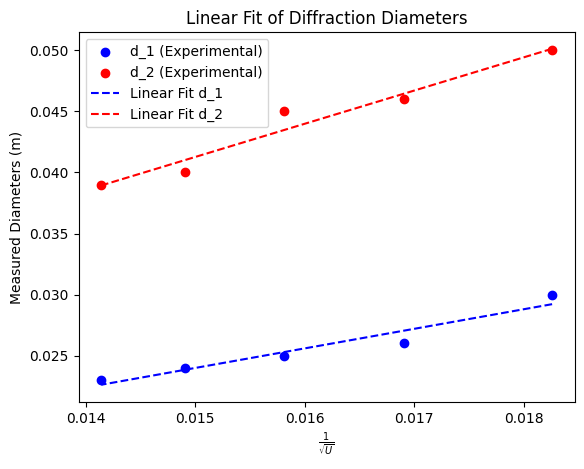


--- Linear Regression Slopes ---
Slope for d_1: 1.604e+00
Slope for d_2: 2.721e+00


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import math
from sklearn.linear_model import LinearRegression

# Constants
L = 0.135  # Distance from graphite layer to screen (m)
d_1 = 2.13 * 10**(-10)  # Lattice constant for first diffraction ring (m)
d_2 = 1.23 * 10**(-10)  # Lattice constant for second diffraction ring (m)
h = 6.626 * 10**(-34)  # Planck's constant (J·s)
m = 9.109 * 10**(-31)  # Electron mass (kg)
e = 1.602 * 10**(-19)  # Electron charge (C)
U = np.array([3.0, 3.5, 4.0, 4.5, 5.0])  # Accelerating voltage (kV)

# Convert kV to V
U *= 10**3  

# Helper functions
def sqrt_U(U):
    """Compute 1/sqrt(U) for regression."""
    return 1 / np.sqrt(U)

def read_csv(filename):
    """Read CSV file and return as NumPy array."""
    return np.genfromtxt(filename, delimiter=',')

def lambda_exp(d, D, L):
    """Calculate experimental wavelength using λ = d * D / (2L)."""
    return d * D / (2 * L)

def lambda_theo(h, m, e, U):
    """Calculate theoretical de Broglie wavelength λ = h / sqrt(2meU)."""
    return h / np.sqrt(2 * m * e * U)

def k_d(D, U):
    """Compute k(D) = D * sqrt(U)."""
    return D * np.sqrt(U)

def d_exp(k, h, L, m, e):
    """Calculate experimental lattice constant d_exp."""
    return (2 * h * L) / (k * np.sqrt(2 * m * e))

def main():
    """Main function to process data and perform calculations."""
    
    # Read and process experimental data
    d_array = read_csv('data/results.csv')
    d_array = np.delete(d_array, 0, 0)  # Remove first row (headers)
    d_array = np.delete(d_array, 0, 1)  # Remove first column

    # Convert cm to meters
    d_array *= 10**(-2)

    # Separate data into two sets (corresponding to d_1 and d_2)
    d_1_array, d_2_array = d_array[:, 0], d_array[:, 1]

    # Calculate experimental wavelengths
    lambda_1_exp = lambda_exp(d_1, d_1_array, L)
    lambda_2_exp = lambda_exp(d_2, d_2_array, L)

    # Calculate theoretical wavelengths
    lambda_theo_array = np.array([lambda_theo(h, m, e, U_i) for U_i in U])

    # Compute sqrt(U) for regression analysis
    U_sqrt = np.array([sqrt_U(U_i) for U_i in U])

    # Compute k(D) values
    k_D_1 = np.array([k_d(d_1_array[i], U[i]) for i in range(len(U))])
    k_D_2 = np.array([k_d(d_2_array[i], U[i]) for i in range(len(U))])

    # Compute experimental lattice constants
    d_exp_1 = d_exp(k_D_1, h, L, m, e)
    d_exp_2 = d_exp(k_D_2, h, L, m, e)

    # Print results
    print("\n--- Experimental Wavelengths ---")
    for i in range(len(U)):
        print(f"U = {U[i]} V | λ_1_exp = {lambda_1_exp[i]:.3e} m | λ_2_exp = {lambda_2_exp[i]:.3e} m")

    print("\n--- Theoretical Wavelengths ---")
    for i in range(len(U)):
        print(f"U = {U[i]} V | λ_theo = {lambda_theo_array[i]:.3e} m")

    print("\n--- Experimental Lattice Constants ---")
    for i in range(len(U)):
        print(f"U = {U[i]} V | d_1_exp = {d_exp_1[i]:.3e} m | d_2_exp = {d_exp_2[i]:.3e} m")

    # Perform linear regression
    model_d_1 = LinearRegression().fit(U_sqrt.reshape(-1,1), d_1_array)
    model_d_2 = LinearRegression().fit(U_sqrt.reshape(-1,1), d_2_array)

    # Plot results
    plt.scatter(U_sqrt, d_1_array, label="d_1 (Experimental)", color="blue")
    plt.scatter(U_sqrt, d_2_array, label="d_2 (Experimental)", color="red")
    plt.plot(U_sqrt, model_d_1.predict(U_sqrt.reshape(-1,1)), label="Linear Fit d_1", linestyle="dashed", color="blue")
    plt.plot(U_sqrt, model_d_2.predict(U_sqrt.reshape(-1,1)), label="Linear Fit d_2", linestyle="dashed", color="red")

    plt.xlabel("$\\frac{1}{\\sqrt{U}}$")
    plt.ylabel("Measured Diameters (m)")
    plt.legend()
    plt.title("Linear Fit of Diffraction Diameters")
    plt.show()

    # Print regression slopes
    print("\n--- Linear Regression Slopes ---")
    print(f"Slope for d_1: {model_d_1.coef_[0]:.3e}")
    print(f"Slope for d_2: {model_d_2.coef_[0]:.3e}")

if __name__ == "__main__":
    main()
